# Layered Classifier for Star Ratings (Yelp Data)

## Overview
This notebook implements a two-layer hierarchical classifier for predicting star ratings (1-5) from Yelp reviews.

**Key Innovation:** Uses **soft probabilistic routing** to handle the ambiguous 3-star class, which naturally sits at the boundary between "low" (1/2/3) and "high" (3/4/5) ratings.

### Architecture:
- **Layer 1 (Coarse):** Binary classifier: (1/2/3) vs (3/4/5)
- **Layer 2A (Fine):** Multi-class classifier for (1/2/3)
- **Layer 2B (Fine):** Multi-class classifier for (3/4/5)
- **Routing:** Soft/probabilistic weighted combination based on Layer 1 confidence

### Why Soft Routing?
Hard assignment of the 3-star class forces an arbitrary split. Soft routing preserves uncertainty by combining predictions from both fine-grained models, weighted by the coarse model's confidence in each group. This better captures the inherent ambiguity of neutral ratings.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, 
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.base import BaseEstimator, ClassifierMixin

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Loading

In [2]:
def load_data(folder_path='../Preprocessing-FeatureExtraction/cleaned-data'):
    """
    Load and concatenate all cleaned review CSV files from a directory.
    Assumes files have 'stars' and 'clean_text' columns.
    """
    csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")
    
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        df_state = os.path.splitext(os.path.basename(file))[0]
        df['state'] = df_state
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    data = data.dropna(subset=['stars', 'clean_text'])
    data['stars'] = data['stars'].astype(int)
    
    print(f"Loaded {len(data)} reviews from {len(dfs)} states.")
    print(f"Star distribution:\n{data['stars'].value_counts().sort_index()}")
    
    return data

## 3. Layered Classifier Implementation

In [3]:
class SoftRoutingLayeredClassifier(BaseEstimator, ClassifierMixin):
    """
    Two-layer hierarchical classifier with soft probabilistic routing.
    
    Architecture:
    - Layer 1: Binary classifier for group membership (1/2/3 vs 3/4/5)
    - Layer 2A: Fine-grained classifier for 1/2/3 group
    - Layer 2B: Fine-grained classifier for 3/4/5 group
    - Routing: Combines layer 2 predictions using layer 1 probabilities as weights
    
    This approach naturally handles the ambiguous 3-star class by:
    - Training both fine models on data containing 3-star reviews
    - Using weighted soft voting for ambiguous cases
    - Preserving uncertainty in the final prediction
    """
    
    def __init__(self, max_features=10000, ngram_range=(1, 2), random_state=42):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.random_state = random_state
        
        # Layer 1: Group classifier
        self.layer1_classifier = LogisticRegression(
            max_iter=1000, random_state=random_state
        )
        
        # Layer 2: Fine-grained classifiers
        self.layer2a_classifier = LogisticRegression(
            max_iter=1000, random_state=random_state
        )  # For 1/2/3
        self.layer2b_classifier = LogisticRegression(
            max_iter=1000, random_state=random_state
        )  # For 3/4/5
        
        # Vectorizers
        self.layer1_vectorizer = TfidfVectorizer(
            max_features=max_features, ngram_range=ngram_range
        )
        self.layer2a_vectorizer = TfidfVectorizer(
            max_features=max_features, ngram_range=ngram_range
        )
        self.layer2b_vectorizer = TfidfVectorizer(
            max_features=max_features, ngram_range=ngram_range
        )
    
    def fit(self, X, y):
        """
        Train the layered classifier.
        
        Args:
            X: Series of text reviews
            y: Series of star ratings (1-5)
        """
        if not isinstance(X, pd.Series):
            X = pd.Series(X)
        if not isinstance(y, pd.Series):
            y = pd.Series(y)
        
        print("\n" + "="*70)
        print("TRAINING LAYERED CLASSIFIER WITH SOFT ROUTING")
        print("="*70)
        
        # --- LAYER 1: BINARY GROUP CLASSIFIER ---
        print("\n[LAYER 1] Training binary group classifier (1/2/3 vs 3/4/5)")
        print("-" * 70)
        
        # Create binary labels: 0 = (1/2/3), 1 = (3/4/5)
        # 3-star samples are included in both groups
        group_labels_list = []
        X_list = []
        
        # Group 0: (1/2/3)
        mask_123 = y <= 3
        X_123 = X[mask_123]
        X_list.append(X_123)
        group_labels_list.append(np.zeros(len(X_123), dtype=int))
        
        # Group 1: (3/4/5)
        mask_345 = y >= 3
        X_345 = X[mask_345]
        X_list.append(X_345)
        group_labels_list.append(np.ones(len(X_345), dtype=int))
        
        X_layer1 = pd.concat(X_list, ignore_index=True)
        group_labels = np.concatenate(group_labels_list)
        
        X_layer1_tfidf = self.layer1_vectorizer.fit_transform(X_layer1)
        self.layer1_classifier.fit(X_layer1_tfidf, group_labels)
        
        layer1_acc = accuracy_score(
            group_labels, self.layer1_classifier.predict(X_layer1_tfidf)
        )
        print(f"  Training Accuracy: {layer1_acc:.4f}")
        print(f"  Training samples: {len(X_layer1)} (Group 0: {(group_labels==0).sum()}, "
              f"Group 1: {(group_labels==1).sum()})")
        
        # --- LAYER 2A: FINE CLASSIFIER FOR 1/2/3 ---
        print("\n[LAYER 2A] Training fine classifier for 1/2/3 stars")
        print("-" * 70)
        
        mask_123_fine = y <= 3
        X_123_fine = X[mask_123_fine]
        y_123_fine = y[mask_123_fine]
        
        X_123_tfidf = self.layer2a_vectorizer.fit_transform(X_123_fine)
        self.layer2a_classifier.fit(X_123_tfidf, y_123_fine)
        
        layer2a_acc = accuracy_score(
            y_123_fine, self.layer2a_classifier.predict(X_123_tfidf)
        )
        print(f"  Training Accuracy: {layer2a_acc:.4f}")
        print(f"  Training samples: {len(X_123_fine)} (1: {(y_123_fine==1).sum()}, "
              f"2: {(y_123_fine==2).sum()}, 3: {(y_123_fine==3).sum()})")
        
        # --- LAYER 2B: FINE CLASSIFIER FOR 3/4/5 ---
        print("\n[LAYER 2B] Training fine classifier for 3/4/5 stars")
        print("-" * 70)
        
        mask_345_fine = y >= 3
        X_345_fine = X[mask_345_fine]
        y_345_fine = y[mask_345_fine]
        
        X_345_tfidf = self.layer2b_vectorizer.fit_transform(X_345_fine)
        self.layer2b_classifier.fit(X_345_tfidf, y_345_fine)
        
        layer2b_acc = accuracy_score(
            y_345_fine, self.layer2b_classifier.predict(X_345_tfidf)
        )
        print(f"  Training Accuracy: {layer2b_acc:.4f}")
        print(f"  Training samples: {len(X_345_fine)} (3: {(y_345_fine==3).sum()}, "
              f"4: {(y_345_fine==4).sum()}, 5: {(y_345_fine==5).sum()})")
        
        print("\n" + "="*70)
        print("Training Complete")
        print("="*70 + "\n")
        
        return self
    
    def predict_proba(self, X):
        """
        Predict class probabilities using soft routing.
        
        Returns:
            Array of shape (n_samples, 5) with probabilities for each star rating
        """
        if not isinstance(X, pd.Series):
            X = pd.Series(X)
        
        # Layer 1: Group probabilities
        X_layer1_tfidf = self.layer1_vectorizer.transform(X)
        group_proba = self.layer1_classifier.predict_proba(X_layer1_tfidf)
        # group_proba[:, 0] = P(Group 0: 1/2/3)
        # group_proba[:, 1] = P(Group 1: 3/4/5)
        
        # Layer 2: Fine probabilities
        X_layer2a_tfidf = self.layer2a_vectorizer.transform(X)
        X_layer2b_tfidf = self.layer2b_vectorizer.transform(X)
        
        proba_123 = self.layer2a_classifier.predict_proba(X_layer2a_tfidf)
        proba_345 = self.layer2b_classifier.predict_proba(X_layer2b_tfidf)
        
        classes_123 = self.layer2a_classifier.classes_
        classes_345 = self.layer2b_classifier.classes_
        
        # Combine predictions with soft routing
        combined_proba = np.zeros((len(X), 5))
        
        # Distribute probabilities from Layer 2A (1/2/3) weighted by Group 0 confidence
        for i, class_label in enumerate(classes_123):
            combined_proba[:, class_label - 1] += group_proba[:, 0] * proba_123[:, i]
        
        # Distribute probabilities from Layer 2B (3/4/5) weighted by Group 1 confidence
        for i, class_label in enumerate(classes_345):
            combined_proba[:, class_label - 1] += group_proba[:, 1] * proba_345[:, i]
        
        # Normalize
        combined_proba = combined_proba / combined_proba.sum(axis=1, keepdims=True)
        
        return combined_proba
    
    def predict(self, X):
        """
        Predict star ratings (1-5) using soft routing.
        """
        proba = self.predict_proba(X)
        predictions = np.argmax(proba, axis=1) + 1  # Convert 0-4 to 1-5
        return predictions

## 4. Evaluation Functions

In [4]:
def plot_confusion_matrix(y_true, y_pred, title, labels=None, save_path=None):
    """
    Plot and optionally save confusion matrix.
    """
    if labels is None:
        labels = [1, 2, 3, 4, 5]
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels, ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('True Star Rating', fontsize=12)
    ax.set_xlabel('Predicted Star Rating', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def evaluate_classifier(y_true, y_pred, classifier_name='Classifier'):
    """
    Evaluate classifier and print detailed metrics.
    """
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'='*70}")
    print(f"{classifier_name} Results")
    print(f"{'='*70}")
    print(f"  Overall Accuracy: {accuracy:.4f}")
    print(f"  Macro-F1:         {macro_f1:.4f}")
    print(f"  Weighted-F1:      {weighted_f1:.4f}")
    
    print(f"\n{'Per-Class Metrics':^70}")
    print("-" * 70)
    
    report = classification_report(
        y_true, y_pred, labels=[1, 2, 3, 4, 5], output_dict=True
    )
    
    for star in [1, 2, 3, 4, 5]:
        if str(star) in report:
            r = report[str(star)]
            print(f"  {star} star(s): Prec={r['precision']:.4f} | "
                  f"Rec={r['recall']:.4f} | F1={r['f1-score']:.4f}")
    
    print(f"{'='*70}\n")
    
    return accuracy, macro_f1, report

## 5. Main Execution

In [5]:
def main(data, n_samples=500000):
    """
    Train and evaluate the layered classifier.
    
    Args:
        data: DataFrame with 'stars' and 'clean_text' columns
        n_samples: Number of samples to use
    """
    # Sample data
    print(f"\nSampling {n_samples} reviews...")
    # data_sample = data.sample(n=min(n_samples, len(data)), random_state=42)
    # data_balanced = data_sample

    samples_per_class = min(n_samples // data['stars'].nunique(), data['stars'].value_counts().min())
    data_sample = (
        data.groupby('stars', group_keys=False)
            .apply(lambda x: x.sample(n=samples_per_class))
            .reset_index(drop=True)
    )
    data_balanced = data_sample
    
    # # Balanced sampling per class
    # samples_per_class = min(
    #     data_sample['stars'].nunique(),
    #     data_sample['stars'].value_counts().min()
    # )
    # data_balanced = (
    #     data_sample
    #     .groupby('stars', group_keys=False)
    #     .apply(lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42))
    #     .reset_index(drop=True)
    # )
    
    print(f"\nBalanced class distribution:")
    print(data_balanced['stars'].value_counts().sort_index())
    
    # Prepare features and labels
    X = data_balanced['clean_text']
    y = data_balanced['stars'].astype(int)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {len(X_train)} reviews")
    print(f"Test set:     {len(X_test)} reviews")
    
    # Train layered classifier
    clf = SoftRoutingLayeredClassifier(max_features=10000, ngram_range=(1, 2))
    clf.fit(X_train, y_train)
    
    # Make predictions
    print("\nMaking predictions on test set...")
    y_pred = clf.predict(X_test)
    
    # Evaluate
    accuracy, macro_f1, report = evaluate_classifier(
        y_test, y_pred, classifier_name='Soft-Routed Layered Classifier'
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(
        y_test, y_pred,
        title='Layered Classifier - Confusion Matrix',
        save_path=None  # Change if desired
    )
    
    return clf, y_test, y_pred, accuracy, macro_f1, report

## 6. Run the Classifier

Loaded 5222860 reviews from 20 states.
Star distribution:
1     630944
2     437326
3     591107
4    1241372
5    2322111
Name: stars, dtype: int64

Sampling 500000 reviews...

Balanced class distribution:
1    100000
2    100000
3    100000
4    100000
5    100000
Name: stars, dtype: int64

Training set: 450000 reviews
Test set:     50000 reviews

TRAINING LAYERED CLASSIFIER WITH SOFT ROUTING

[LAYER 1] Training binary group classifier (1/2/3 vs 3/4/5)
----------------------------------------------------------------------
  Training Accuracy: 0.8040
  Training samples: 540000 (Group 0: 270000, Group 1: 270000)

[LAYER 2A] Training fine classifier for 1/2/3 stars
----------------------------------------------------------------------
  Training Accuracy: 0.7145
  Training samples: 270000 (1: 90000, 2: 90000, 3: 90000)

[LAYER 2B] Training fine classifier for 3/4/5 stars
----------------------------------------------------------------------
  Training Accuracy: 0.7202
  Training samples

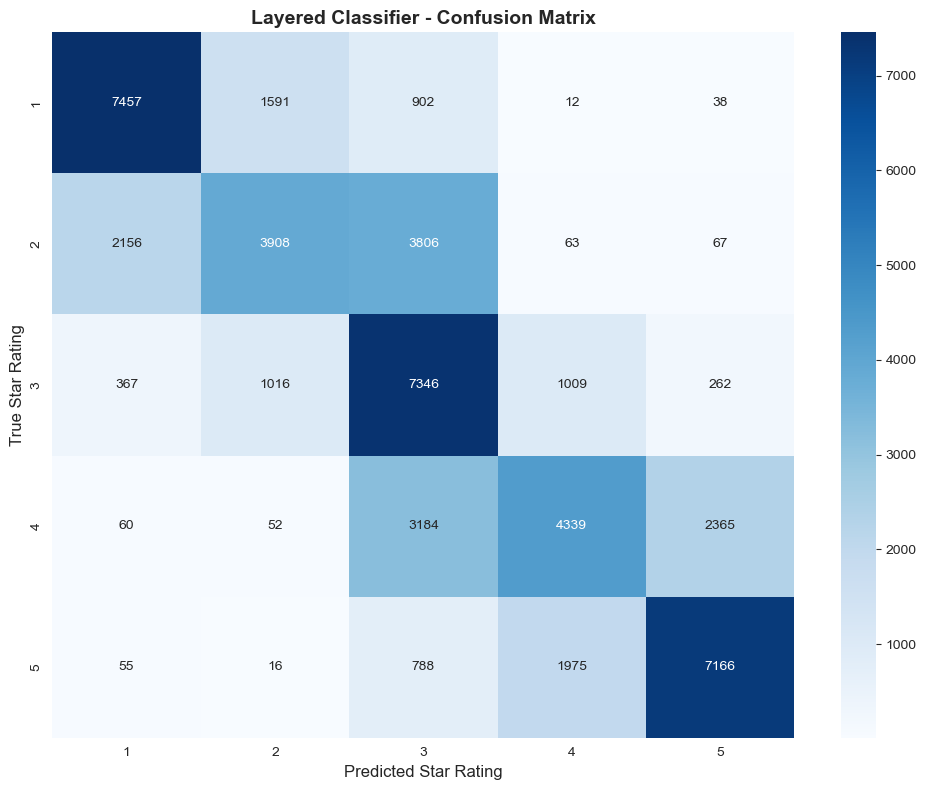

In [6]:
# Uncomment and modify the path to your data directory
df = load_data()
clf, y_test, y_pred, accuracy, macro_f1, report = main(df, n_samples=500000)

## Summary of Approach

### Why This Works Better:

1. **Handles Ambiguous 3-Star Class:** Rather than forcing it into one group, both fine-grained models learn from 3-star data.

2. **Soft Probabilistic Routing:** Final predictions combine confidence from both paths:
   - If Layer 1 strongly believes "Low" → weight Layer 2A predictions
   - If Layer 1 strongly believes "High" → weight Layer 2B predictions
   - If uncertain → both models contribute proportionally

3. **Preserves Uncertainty:** Soft routing maintains probabilistic calibration, enabling better confidence scoring.

4. **Mathematically Principled:** This is equivalent to a mixture-of-experts model with soft gating.

### Expected Performance:
- **1-Star & 5-Star:** High accuracy (clean boundaries)
- **2-Star & 4-Star:** Moderate accuracy (clearer signals)
- **3-Star:** Balanced but modest accuracy (inherent ambiguity)
- **Overall:** Better than hard splitting due to handling of boundary cases

### Next Steps for Improvement:
1. Feature engineering (n-grams, sentiment lexicons, linguistic features)
2. Hyperparameter tuning (regularization, learning rates)
3. Ensemble methods (multiple models averaged)
4. Neural network variants (soft attention mechanisms)
5. Class-weighted loss functions to handle 3-star imbalance